In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.nearest import Tile2SymbNearest

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]


def make_converter(params: Params):
    return Tile2SymbNearest(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.0442 | Max: 0.2120 | Mean: 0.1212 | Std: 0.0482
Min: 0.0449 | Max: 0.2329 | Mean: 0.1267 | Std: 0.0554
Min: 0.0711 | Max: 0.3098 | Mean: 0.1708 | Std: 0.0685
Min: 0.0133 | Max: 0.3537 | Mean: 0.1690 | Std: 0.0952


C:\Users\wojte\AppData\Local\Temp\ipykernel_14096\2314016341.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


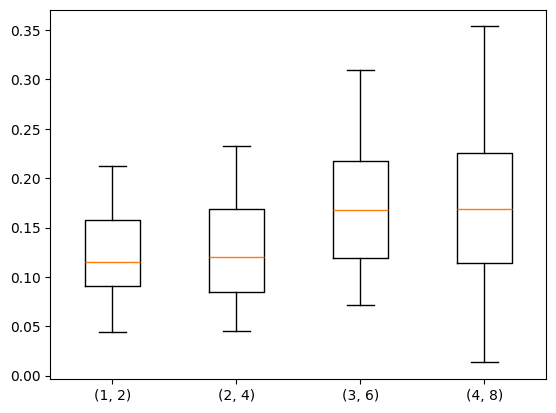

In [2]:
# val_wh

params_space = [
    (w, w * 2) for w in range(1, 5, 1)
]

params_space = list(
    map(lambda val_wh: Params(
        win_width=val_wh[0],
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'val_wh': val_wh},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['val_wh'] for param in params_space])
plt.show()

Min: -0.0138 | Max: 0.2138 | Mean: 0.0909 | Std: 0.0624
Min: 0.0444 | Max: 0.2785 | Mean: 0.1490 | Std: 0.0703
Min: 0.1099 | Max: 0.3440 | Mean: 0.2045 | Std: 0.0697
Min: 0.1449 | Max: 0.3617 | Mean: 0.2376 | Std: 0.0634
Min: 0.1640 | Max: 0.3661 | Mean: 0.2506 | Std: 0.0591


C:\Users\wojte\AppData\Local\Temp\ipykernel_14096\2354411618.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


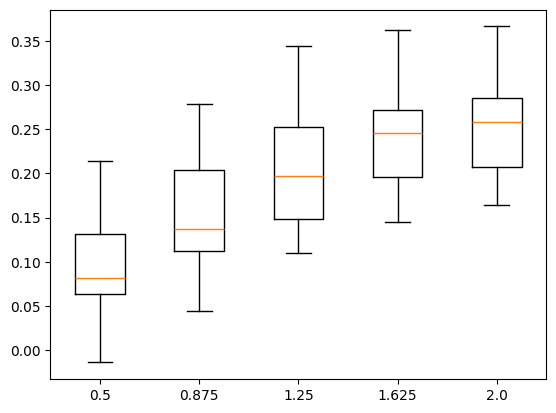

In [3]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        win_width=3,
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [4]:
import math
from PIL import Image
from converters.img_converter import ImgConverter
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2SymbNearest(symbols=SYMBOLS,
                             font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = ImgConverter(converter).img2symbols(img, (3, 6), MAX_WIDTH, MAX_HEIGHT)
    results.append(res_arr)

print_gallery(results, 2)

d:\CS Projects\python-playground\python-ascii-art\tests\experimental\grayscale\tile\../../../../src\converters\tile\nearest.py:39: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


---------------------------------------------------------------
 | "=99@@@m#Qgg#==sm@{ssssss-  | f$$@$Qgg&Q{]$@QQQQ$QQB[$$Q[ | 
 | _g_____jj_________          | 9[9t]Q@QQQ{]08Q$$@$@Q&@@@f` | 
 | QQQQQQQQQQQQQQQQQQQQQQQQQQ[ | ~`{jj@Qg$QQ~t`"98@$,{{)[jsr | 
 | QQQQQQQQ$$QQQQQQQQQQQQQQQQ[ | jggQQQQ$[""f"   ][Q@[@QQgQ[ | 
 | QQQQQQ$`~~~~]$QQQQQQQQQQQQt | Q@@Q8QQgQQ[     ]Q8QQQQQQQL | 
 | QQQQQ$ggjgjg]QQQQQQQggQQQQ[ | 9QgggQ$QQQQ-    ]QQ@QQgj89` | 
 | QQQQQQQQQQQQQQQQQQQQQQQQQQ[ | j@QQQQQQQQQ[    jQQQQ@$gg{` | 
 | QQQQQQQQQQQ$QQQ$QQQQQQQQQQ[ | jQ88QQQQQQQ[   yf""3QQ@9@8L | 
 | QQ$QQ$QQ$$Q$QQQQQQQQQQQQQQL | Q88Qf@Q@QQQ``,9Qs _ ~9@88QL | 
---------------------------------------------------------------
 | @@@8&85`~``sjgg&@){gg$8F~.  |              | 
 | ss{{{)~~~)ss88{""````~- ~~` | ____________ | 
 | {{{{{{{{{j)){jgg{~ss{s{{~jr | QQQQQQQQQQQQ | 
 | {{{9#[]QQQQ@Q$$8$ggQg$$QQ$[ | QQQQ88@@QQQQ | 
 | {{{@{f9@@Q8{8QQ8@@$@@f`f@@` | QQQQ#]["QQQQ | 
 | 8999{{t   "{9f99t9{{f){"`   | QQQQ[   ]QQQ | 
 |